# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
import pandas as pd # importar librerías

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv') #completa el código
usage = pd.read_csv('/datasets/usage.csv') #completa el código

In [3]:
plans.head() # mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
users.head() # mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
usage.head() # mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
plans.info() # inspección de plans con .info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
users.info() # inspección de users con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
usage.info() # inspección de usage con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:


users["city"].isna().sum() # cantidad de nulos para users
print("city", users["city"].isna().sum()) # Cantidad de valores nulos
print(f"El porcentaje de valores nulos es: {users['city'].isna().mean() * 100}%") # Proporción de valores nulos


city 469
El porcentaje de valores nulos es: 11.725%


In [11]:
usage["date"].isna().sum() # cantidad de nulos para usage
print(f"El porcentaje de valores nulos es: {usage['date'].isna().mean() * 100}%")

El porcentaje de valores nulos es: 0.125%


###### ✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.


Hallazgo: Se identificó la presencia de valores nulos en la columna 'date', los cuales representan únicamente el 0.125% del total de los registros del conjunto de datos 'usage'.

Justificación: Debido a que el porcentaje de datos faltantes es extremadamente bajo, su eliminación no compromete la representatividad de la muestra. Por el contrario, evita errores o comportamientos inesperados en análisis temporales posteriores.

Acción recomendada: Eliminar las filas con valores nulos en esta columna específica utilizando el método .dropna(subset=['date']) para asegurar un DataFrame limpio y consistente.

Hallazgo: Se identificó la presencia de valores nulos en la columna 'city', los cuales representan el 11.72% del total de los registros del conjunto de datos.

Justificación: Al encontrarse en el rango del 5% al 30%, no se recomienda eliminar estas filas directamente, ya que perderíamos una cantidad considerable de información valiosa. Tampoco se debe ignorar la columna, por lo que es necesario investigar si existe un patrón en los datos faltantes para decidir si dejamos los nulos como una categoría o si realizamos una imputación.

Acción recomendada: Investigar el comportamiento de los nulos en 'city' (por ejemplo, ver si están relacionados con ciertos países o tipos de usuarios). Dependiendo del hallazgo, imputar los datos usando la moda o crear una categoría explícita como 'Desconocido' para no perder estos registros en los análisis posteriores.




💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.
 - 
Justificación date : Debido a que el porcentaje de datos faltantes es extremadamente bajo, su eliminación no compromete la representatividad de la muestra. Por el contrario, evita errores o comportamientos inesperados en análisis temporales posteriores.
Acción recomendada: Eliminar las filas con valores nulos en esta columna específica utilizando el método .dropna(subset=['date']) para asegurar un DataFrame limpio y consistente.

Justificación city: Al encontrarse en el rango del 5% al 30%, no se recomienda eliminar estas filas directamente, ya que perderíamos una cantidad considerable de información valiosa. Tampoco se debe ignorar la columna, por lo que es necesario investigar si existe un patrón en los datos faltantes para decidir si dejamos los nulos como una categoría o si realizamos una imputación.


**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- date y city
- Indica qué harías: ¿imputar, eliminar, ignorar?
- Date: eliminar; city: imputar

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

-
 

La columna `user_id` 
En resumen, la columna user_id parece representar un identificador numérico único para cada usuario, con valores consecutivos y sin anomalías evidentes. Es una columna estable y útil como clave primaria o referencia en el conjunto de datos.
 
La columna `age` 
Las columnas como age muestran variables numéricas reales, pero presentan una anomalía grave en su valor mínimo (-999.000000). Esto delata la existencia de valores faltantes o nulos mal codificados en el dataset, lo cual altera por completo la desviación estándar (123.23) y distorsiona el análisis real de la edad de los usuarios (la cual debería oscilar normalmente entre 32 y 79 años según los percentiles).



In [12]:
users.describe() # explorar columnas numéricas de usage

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000



Las columnas `id` y `user_id`...
Las columnas id y user_id son identificadores numéricos (variables categóricas). Al ver su resumen estadístico, noto que métricas como el promedio (mean) o la desviación estándar (std) no tienen sentido lógico ni aportan valor real, ya que no son cantidades sumables sino códigos de registro.

In [13]:

# 1. Limpieza inicial: quitar espacios y pasar a minúsculas
users['city'] = users['city'].str.strip().str.lower()

# 2. Diccionario de reemplazo para estandarizar nombres
reemplazos_city  = {
    'cdmx': 'ciudad de méxico',
    'gdl': 'guadalajara',
    'mty': 'monterrey',
    'bogota': 'bogotá',
    'medellin': 'medellín',
    'cali': 'cali',
    '?': pd.NA   # convertir '?' en valor faltante
}

# 3. Aplicar reemplazo
users['city'] = users['city'].replace(reemplazos_city)

# 4. Opcional: capitalizar de forma uniforme

users['city'] = users['city'].str.title()
users['city'] = users['city'].replace({'Ciudad De México': 'Ciudad de México'})
columnas_user = ["city", "plan"]


# 5. Exploración de columnas categóricas
for col in columnas_user:
    print(f"\nColumna: {col}")
    print("Valores únicos:")
    print(users[col].unique())
    print("\nFrecuencia de cada valor:")
    print(users[col].value_counts())

# 6. Resumen estadístico de las columnas categóricas
print("\nResumen estadístico:")
print(users[columnas_user].describe())

# 7. Conteo de valores faltantes
print("\nConteo de valores faltantes:")
print(users.isna().sum())

# 8. Porcentaje de valores faltantes
print("\nPorcentaje de valores faltantes:")
print(users.isna().mean() * 100)




Columna: city
Valores únicos:
['Medellín' <NA> 'Ciudad de México' 'Bogotá' 'Guadalajara' 'Monterrey' nan
 'Cali']

Frecuencia de cada valor:
Bogotá              808
Ciudad de México    730
Medellín            616
Guadalajara         450
Cali                424
Monterrey           407
Name: city, dtype: int64

Columna: plan
Valores únicos:
['Basico' 'Premium']

Frecuencia de cada valor:
Basico     2595
Premium    1405
Name: plan, dtype: int64

Resumen estadístico:
          city    plan
count     3435    4000
unique       6       2
top     Bogotá  Basico
freq       808    2595

Conteo de valores faltantes:
user_id          0
first_name       0
last_name        0
age              0
city           565
reg_date         0
plan             0
churn_date    3534
dtype: int64

Porcentaje de valores faltantes:
user_id        0.000
first_name     0.000
last_name      0.000
age            0.000
city          14.125
reg_date       0.000
plan           0.000
churn_date    88.350
dtype: float64


La columna `city` ...
565 nulos (14.1%), además inconsistencias de formato (mayúsculas/minúsculas, espacios). Se recomienda estandarizar el texto y decidir si imputar o dejar como NA explícito antes de usar esta columna en segmentaciones.
La columna `plan` ...
sin valores nulos, dos categorías bien definidas. Lista para usarse directamente en análisis y segmentación sin necesidad de limpieza adicional.

In [14]:

# 1. Ver valores únicos en la columna type
print("Valores únicos en usage['type']:")
print(usage['type'].unique())

# 2. Contar frecuencia de cada categoría
print("\nFrecuencia de cada valor en usage['type']:")
print(usage['type'].value_counts())

# 3. Resumen estadístico de la columna categórica
print("\nResumen estadístico de usage['type']:")
print(usage['type'].describe())

# 4. Conteo de valores faltantes
print("\nValores faltantes en usage['type']:")
print(usage['type'].isna().sum())

# 5. Porcentaje de valores faltantes
print("\nPorcentaje de valores faltantes en usage['type']:")
print(usage['type'].isna().mean() * 100)

# 6. Crear columnas booleanas a partir de 'type'
usage["is_call"] = usage["type"] == "call"
usage["is_text"] = usage["type"] == "text"

# 7. Verificamos las primeras filas para confirmar
print("\nPrimeras filas con nuevas columnas:")
print(usage.head(5))

Valores únicos en usage['type']:
['call' 'text']

Frecuencia de cada valor en usage['type']:
text    22092
call    17908
Name: type, dtype: int64

Resumen estadístico de usage['type']:
count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

Valores faltantes en usage['type']:
0

Porcentaje de valores faltantes en usage['type']:
0.0

Primeras filas con nuevas columnas:
   id  user_id  type                           date  duration  length  \
0   1    10332  call  2024-01-01 00:00:00.000000000      0.09     NaN   
1   2    11458  text  2024-01-01 00:06:30.969774244       NaN    39.0   
2   3    11777  text  2024-01-01 00:13:01.939548488       NaN    36.0   
3   4    10682  call  2024-01-01 00:19:32.909322733      1.53     NaN   
4   5    12742  call  2024-01-01 00:26:03.879096977      4.84     NaN   

   is_call  is_text  
0     True    False  
1    False     True  
2    False     True  
3     True    False  
4     True    False  


La columna `type` ...
La columna type tiene exactamente 2 categorías distintas: "call" y "text".
No presenta valores nulos ni vacíos (0 faltantes, 0%).
Por lo tanto, la columna está limpia y lista para análisis directo, ya que sus categorías son claras, completas y no requieren corrección de formato.

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
¿En qué columnas encontraste valores inválidos o sentinels?

En la columna city detectamos el símbolo '?' usado como sentinel para “dato faltante”. También vimos inconsistencias de formato (mayúsculas/minúsculas, espacios extra, abreviaciones como cdmx, gdl, mty, y variaciones con/ sin acento).

En la columna churn_date los valores nulos no son errores de captura, sino que funcionan como sentinel: indican que el usuario no ha cancelado el servicio (activo).

En la columna age aunque no hay nulos (isna().sum() = 0), sí se detectó el sentinel -999 en la celda 19. Este valor no es un NaN, pero es inválido y debe tratarse como tal.

En la columna Usage['type'] ninguno. Tiene exactamente dos categorías ("call" y "text") y 0 valores faltantes.

¿Qué acción tomarías?

Para city: reemplazar '?' por NaN, aplicar limpieza de formato (strip, lower) y estandarizar con un diccionario de reemplazo. Luego decidir si los NaN se mantienen como faltantes o se agrupan en una categoría explícita como "Desconocido".

Para churn_date: no imputar valores, sino reinterpretar los NaN como “usuario activo”. Una acción útil es crear una columna booleana is_churned (True si tiene fecha, False si está vacío).

Para plan y usage['type']: no se encontraron valores inválidos ni sentinels; ambas columnas están limpias y listas para análisis directo.
Para age  reemplazar -999 por NaN para que pandas lo reconozca como dato faltante. Además, revisar rangos razonables (ej. 0–100 años) para detectar otros posibles outliers.


### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [15]:
# 1. Convertir reg_date a tipo fecha (a prueba de errores)
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

# 2. Contar cuántos registros tienen año 2026
registros_2026 = users[users['reg_date'].dt.year == 2026]
num_registros_2026 = len(registros_2026)

# 3. Calcular el porcentaje respecto al total de usuarios
total_usuarios = len(users)
porcentaje_2026 = (num_registros_2026 / total_usuarios) * 100

print(f"Registros con año 2026: {num_registros_2026}")
print(f"Porcentaje respecto al total ({total_usuarios}): {porcentaje_2026:.2f}%")

# 4. Mostrar los registros con año 2026 para revisión
print("\nRegistros con año 2026 detectados:")
print(registros_2026[['user_id', 'reg_date']])

Registros con año 2026: 40
Porcentaje respecto al total (4000): 1.00%

Registros con año 2026 detectados:
      user_id   reg_date
40      10040 2026-05-10
56      10056 2026-05-10
60      10060 2026-05-10
70      10070 2026-05-10
248     10248 2026-05-10
320     10320 2026-05-10
326     10326 2026-05-10
505     10505 2026-05-10
527     10527 2026-05-10
646     10646 2026-05-10
885     10885 2026-05-10
914     10914 2026-05-10
948     10948 2026-05-10
986     10986 2026-05-10
1047    11047 2026-05-10
1210    11210 2026-05-10
1275    11275 2026-05-10
1293    11293 2026-05-10
1314    11314 2026-05-10
1627    11627 2026-05-10
1679    11679 2026-05-10
1722    11722 2026-05-10
1736    11736 2026-05-10
1737    11737 2026-05-10
1862    11862 2026-05-10
1880    11880 2026-05-10
1896    11896 2026-05-10
2055    12055 2026-05-10
2093    12093 2026-05-10
2111    12111 2026-05-10
2162    12162 2026-05-10
2184    12184 2026-05-10
2200    12200 2026-05-10
2235    12235 2026-05-10
2307    12307 2026-

In [16]:
# 1. Convertir a tipo fecha la columna date (a prueba de errores)
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

# 2. Revisar cuántas veces aparece cada año
print("\nFrecuencia por año en usage['date']:")
print(usage['date'].dt.year.value_counts().sort_index())

# 3. Identificar fechas imposibles
# - años futuros (mayores a 2024)
# - años negativos o nulos
fechas_invalidas_usage = usage[
    (usage['date'].dt.year > 2024) | 
    (usage['date'].dt.year < 0)
]

print("\nFechas imposibles detectadas en usage['date']:")
print(fechas_invalidas_usage[['date']])


Frecuencia por año en usage['date']:
2024.0    39950
Name: date, dtype: int64

Fechas imposibles detectadas en usage['date']:
Empty DataFrame
Columns: [date]
Index: []


In [17]:
# Revisar los años presentes en reg_date de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

print("\nAños presentes en users['reg_date']:")
print(users['reg_date'].dt.year.value_counts().sort_index())



Años presentes en users['reg_date']:
2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


En `reg_date...
En la columna reg_date se identificaron 40 registros con año 2026, lo que equivale al 1% del total de usuarios (4000). Este año es imposible dentro del rango esperado, ya que los datos solo deberían llegar hasta 2024.

Hipótesis sobre la causa:

Error de digitación (2026 en vez de 2024 o 2025).

Configuración regional o formato de fecha mal interpretado.

Datos de prueba mezclados con registros reales.

Problemas en la migración o carga masiva de datos.

Bug en el sistema que asigna fechas por defecto.

Acción recomendada: marcar estos 40 registros como nulos (NaT) en el proceso de limpieza. Aunque representan un porcentaje pequeño (1%), es importante corregirlos para mantener la coherencia temporal y evitar sesgos en análisis de tendencias.

De esta forma, el diagnóstico queda completo: se cuantifica el impacto, se explica por qué es imposible, se consideran varias hipótesis y se define la acción correctiva.

In [18]:
# Convertir a tipo fecha la columna date (a prueba de errores)
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

# Revisar los años presentes en usage['date']
print("\nAños presentes en usage['date']:")
print(usage['date'].dt.year.value_counts().sort_index())



Años presentes en usage['date']:
2024.0    39950
Name: date, dtype: int64


In [19]:
# Contar cuántos valores quedaron como NaT
num_nat = usage['date'].isna().sum()
print(f"Valores NaT en usage['date']: {num_nat}")

# Mostrar algunos ejemplos de esos registros
print("\nEjemplos de registros con NaT en usage['date']:")
print(usage[usage['date'].isna()].head())

Valores NaT en usage['date']: 50

Ejemplos de registros con NaT en usage['date']:
        id  user_id  type date  duration  length  is_call  is_text
2854  2855    12193  text  NaT       NaN    64.0    False     True
3443  3444    10775  text  NaT       NaN    69.0    False     True
3808  3809    10916  text  NaT       NaN    23.0    False     True
3987  3988    12175  call  NaT      2.43     NaN     True    False
4114  4115    12527  text  NaT       NaN    67.0    False     True


En `date`...  
La columna date representa eventos de uso (llamadas o mensajes).

El 99.875% de los registros (39,950) están en el año 2024, lo cual es consistente con el rango esperado.

El 0.125% restante (50 registros) son inválidos y quedaron como NaT tras la conversión.

Acción recomendada: mantener esos 50 como nulos (NaT) y documentar que corresponden a errores de captura o formatos incorrectos. No hay evidencia de fechas futuras como en reg_date.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

reg_date (users)
Se detectaron 40 registros con año 2026 (≈1%).
Año imposible dentro del rango esperado (hasta 2024).
Acción: marcarlos como nulos (NaT) para mantener coherencia temporal.

date (usage)
La mayoría de registros (39,950 ≈99.875%) son de 2024.
50 registros (≈0.125%) quedaron como NaT por valores inválidos.
Acción: mantenerlos como nulos y documentar que corresponden a errores de captura.

---

## 🧩Paso 3: Limpieza básica de datos
### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.
**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median() 
users['age'] = users['age'].replace(-999, age_mediana) 

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)
# Verificar cambios
print("Valores nulos en city:", users['city'].isna().sum())
users['city'].value_counts(dropna=False)


Valores nulos en city: 565


Bogotá              808
Ciudad de México    730
Medellín            616
NaN                 565
Guadalajara         450
Cali                424
Monterrey           407
Name: city, dtype: int64

In [22]:
# Marcar fechas futuras como NA para reg_date
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT
# Verificar cambios
print("Valores nulos en reg_date:", users['reg_date'].isna().sum())
users['reg_date'].dt.year.value_counts(dropna=False).sort_index()


Valores nulos en reg_date: 40


2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:
# Verificación MAR en usage (Missing At Random) para duration
print("Conteo de nulos en duration por type:")
print(usage.groupby('type')['duration'].apply(lambda x: x.isna().sum()))

print("\nConteo total de registros por type:")
print(usage['type'].value_counts())


Conteo de nulos en duration por type:
type
call        0
text    22076
Name: duration, dtype: int64

Conteo total de registros por type:
text    22092
call    17908
Name: type, dtype: int64


In [24]:
# Verificación MAR en usage (Missing At Random) para length
print("Conteo de nulos en length por type:")
print(usage.groupby('type')['length'].apply(lambda x: x.isna().sum()))

print("\nConteo total de registros por type:")
print(usage['type'].value_counts())


Conteo de nulos en length por type:
type
call    17896
text        0
Name: length, dtype: int64

Conteo total de registros por type:
text    22092
call    17908
Name: type, dtype: int64


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

duration
Los nulos aparecen únicamente cuando type = "text".
Esto no es un dato faltante aleatorio, sino un nulo estructural/lógico: un mensaje de texto no tiene duración en segundos.
Conclusión: los nulos son estructurales y deben conservarse como están.

length
Los nulos aparecen únicamente cuando type = "call".
De nuevo, no es un error de captura, sino un nulo lógico: una llamada no tiene longitud en caracteres.
Conclusión: los nulos son estructurales y deben mantenerse sin imputación.

👉 Acción recomendada:  
No imputar ni eliminar estos nulos. Documentar que son “no aplica” según el tipo de evento (type), ya que expresan la lógica del negocio. Opcionalmente, se pueden crear variables derivadas (is_call, is_text) para facilitar el análisis y evitar confusión.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas
2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [25]:
# Celda 45: Agregar métricas de uso por usuario
# Nota: aquí usamos .agg() con nombres asignados directamente,
# lo que evita tener que renombrar después.
usage_agg = (
    usage.groupby("user_id")
    .agg(
        cant_mensajes=("is_text", "sum"),              # número total de mensajes
        cant_llamadas=("is_call", "sum"),              # número total de llamadas
        cant_minutos_llamada=("duration", "sum")       # total de minutos de llamadas
    )
    .reset_index()
)

# Observar resultado
usage_agg.head(3)


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [26]:

# Celda 46: Comentario explicativo
# Nota: no es necesario renombrar columnas aquí,
# porque en la celda 45 ya se asignaron nombres claros
# directamente dentro de .agg().


In [27]:

# Combinar la tabla agregada con el dataset de usuarios
# Celda 47: Merge con users
# Usamos how="left" para conservar todos los usuarios,
# incluso aquellos sin actividad en usage (que tendrán NaN en métricas).
# Esto asegura que el análisis de segmentación incluya tanto usuarios activos como inactivos.
user_profile = users.merge(usage_agg, on="user_id", how="left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,Ciudad de México,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,Guadalajara,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [28]:

# Celda 48: Resumen estadístico de columnas numéricas
# Objetivo: revisar rangos, valores extremos y distribución
# Incluimos columnas como age, cant_mensajes, cant_llamadas, cant_minutos_llamada

user_profile[["age", "cant_mensajes", "cant_llamadas", "cant_minutos_llamada"]].describe() 



,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [29]:
# Distribución porcentual del tipo de plan
print("\nDistribución porcentual de 'plan' en user_profile:")
print(user_profile["plan"].value_counts(normalize=True) * 100)


Distribución porcentual de 'plan' en user_profile:
Basico     64.875
Premium    35.125
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

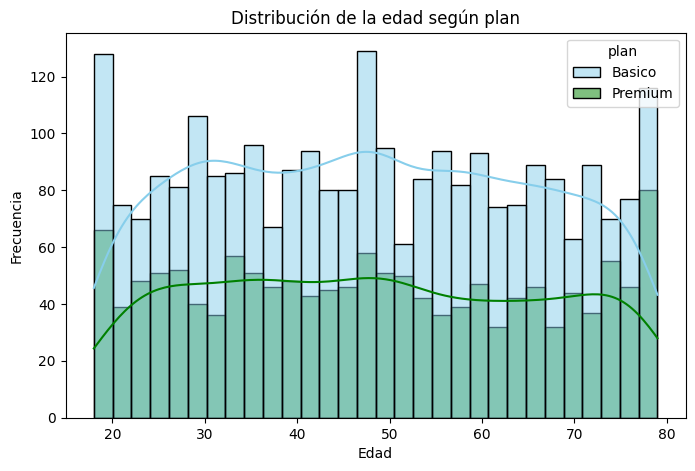

Insight: Dentro del plan Premium, hay mayor proporción de usuarios en edades jóvenes. La distribución es sesgada a la derecha.


In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

# Histograma para visualizar la edad (age)
plt.figure(figsize=(8,5))
sns.histplot(
    data=user_profile,
    x="age",
    hue="plan",
    palette=["skyblue","green"],
    bins=30,
    kde=True
)
plt.title("Distribución de la edad según plan")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()

# Insight de ejemplo (ajusta según tu output real):
print("Insight: Dentro del plan Premium, hay mayor proporción de usuarios en edades jóvenes. La distribución es sesgada a la derecha.")

💡Insights: Dentro del plan Premium, hay mayor proporción de usuarios en edades jóvenes.
- Distribución ...es sesgada a la derecha.

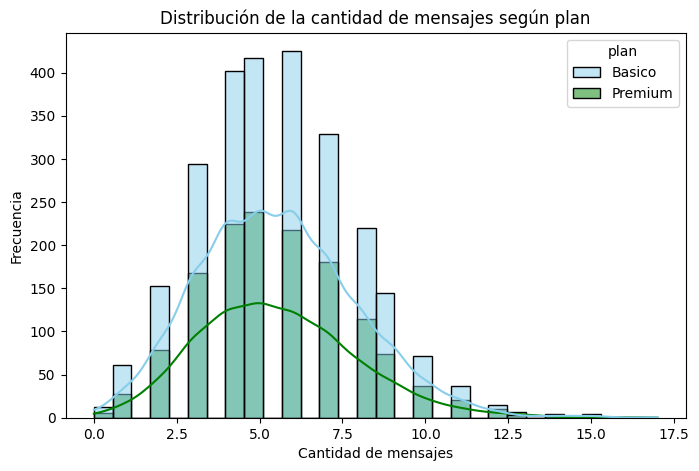

Insight: Los usuarios del plan Básico tienden a enviar menos mensajes, mientras que en Premium se observa mayor proporción de usuarios con volúmenes altos. La distribución es sesgada a la derecha.


In [31]:
# Histograma para visualizar la cant_mensajes
import seaborn as sns
import matplotlib.pyplot as plt

# Histograma para visualizar la cantidad de mensajes (cant_mensajes)
plt.figure(figsize=(8,5))
sns.histplot(
    data=user_profile,
    x="cant_mensajes",
    hue="plan",
    palette=["skyblue","green"],
    bins=30,
    kde=True
)
plt.title("Distribución de la cantidad de mensajes según plan")
plt.xlabel("Cantidad de mensajes")
plt.ylabel("Frecuencia")
plt.show()

# Insight de ejemplo (ajusta según tu output real):
print("Insight: Los usuarios del plan Básico tienden a enviar menos mensajes, mientras que en Premium se observa mayor proporción de usuarios con volúmenes altos. La distribución es sesgada a la derecha.")



💡Insights: Los usuarios del plan Básico tienden a enviar menos mensajes, mientras que en Premium se observa mayor proporción de usuarios con volúmenes altos.
- Distribución ... es sesgada a la derecha.

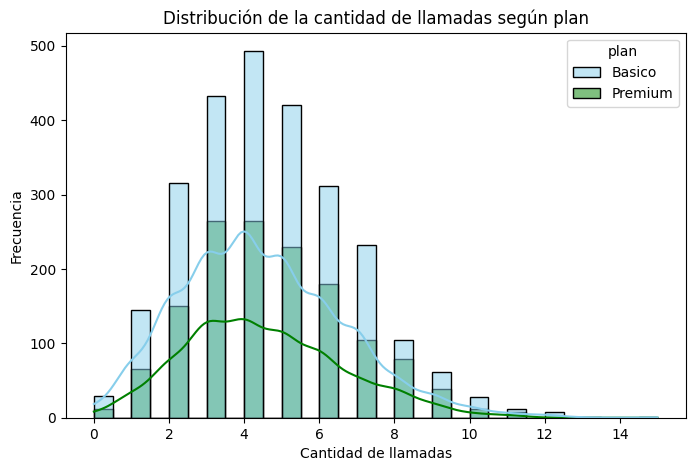

Insight: Los usuarios del plan Básico tienden a realizar menos llamadas, mientras que en Premium se observa mayor variabilidad y más usuarios con volúmenes altos. La distribución es sesgada a la derecha.


In [32]:
# Histograma para visualizar la cant_llamadas
import seaborn as sns
import matplotlib.pyplot as plt

# Histograma para visualizar la cantidad de llamadas (cant_llamadas)
plt.figure(figsize=(8,5))
sns.histplot(
    data=user_profile,
    x="cant_llamadas",
    hue="plan",
    palette=["skyblue","green"],
    bins=30,
    kde=True
)
plt.title("Distribución de la cantidad de llamadas según plan")
plt.xlabel("Cantidad de llamadas")
plt.ylabel("Frecuencia")
plt.show()

# Insight de ejemplo (ajusta según tu output real):
print("Insight: Los usuarios del plan Básico tienden a realizar menos llamadas, mientras que en Premium se observa mayor variabilidad y más usuarios con volúmenes altos. La distribución es sesgada a la derecha.")


💡Insights:Los usuarios del plan Básico tienden a realizar menos llamadas, mientras que en Premium se observa mayor variabilidad y más usuarios con volúmenes altos.
- Distribución ...La distribución es sesgada a la derecha.

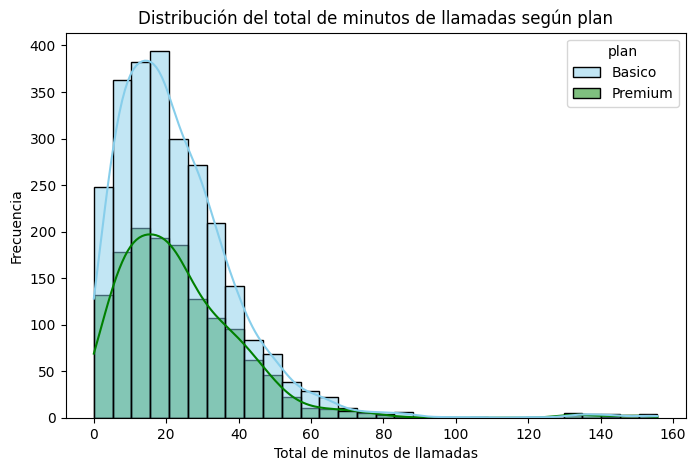

Insight: Los usuarios del plan Premium acumulan más minutos de llamada, mientras que los del plan Básico se concentran en valores bajos. La distribución es sesgada a la derecha.


In [33]:
# Histograma para visualizar la cant_minutos_llamada
import seaborn as sns
import matplotlib.pyplot as plt

# Histograma para visualizar el total de minutos de llamadas (cant_minutos_llamada)
plt.figure(figsize=(8,5))
sns.histplot(
    data=user_profile,
    x="cant_minutos_llamada",
    hue="plan",
    palette=["skyblue","green"],
    bins=30,
    kde=True
)
plt.title("Distribución del total de minutos de llamadas según plan")
plt.xlabel("Total de minutos de llamadas")
plt.ylabel("Frecuencia")
plt.show()

# Insight de ejemplo (ajusta según tu output real):
print("Insight: Los usuarios del plan Premium acumulan más minutos de llamada, mientras que los del plan Básico se concentran en valores bajos. La distribución es sesgada a la derecha.")


💡Insights: Los usuarios del plan Premium acumulan más minutos de llamada, mientras que los del plan Básico se concentran en valores bajos. 
- Distribución... La distribución es sesgada a la derecha.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

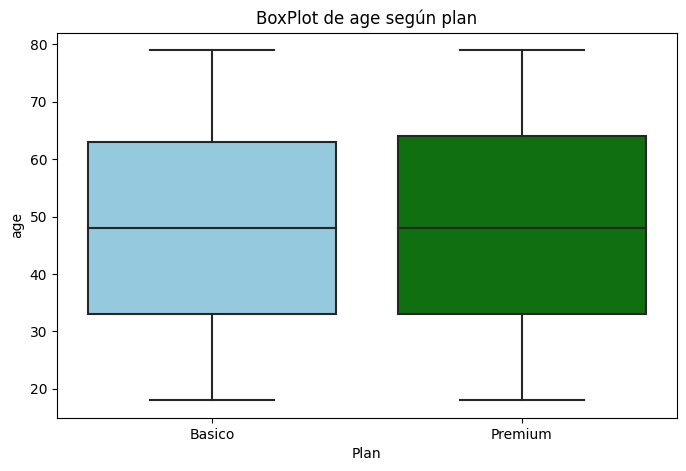

💡 Insight Age: La variable age presenta una distribución simétrica y realista (18–79 años), sin outliers ni valores irreales, por lo que puede mantenerse tal cual en el dataset para análisis y segmentación. La distribución es simétrica.


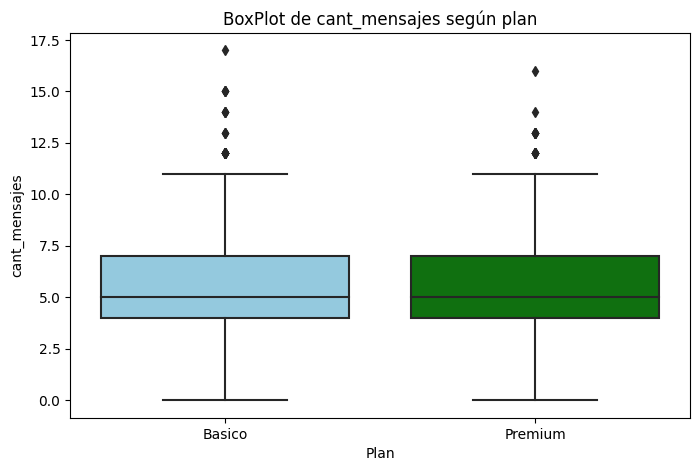

💡 Insight cant_mensajes: Los usuarios Premium muestran mayor dispersión y algunos outliers con volúmenes muy altos de mensajes. Básico se concentra en valores bajos.


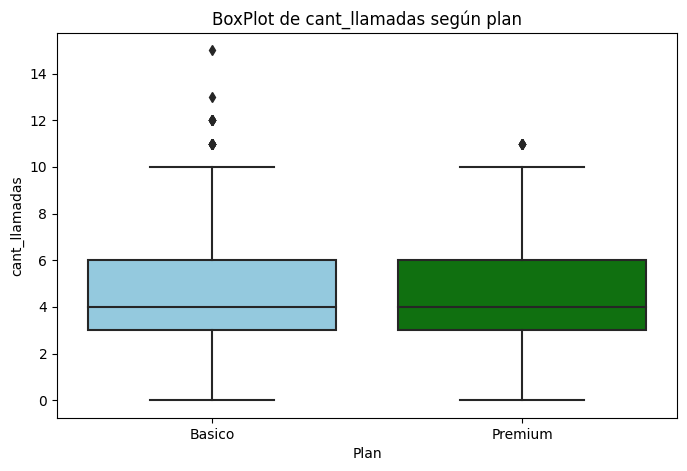

💡 Insight cant_llamadas: Se observan outliers en ambos planes, aunque Premium presenta mayor variabilidad en el número de llamadas.


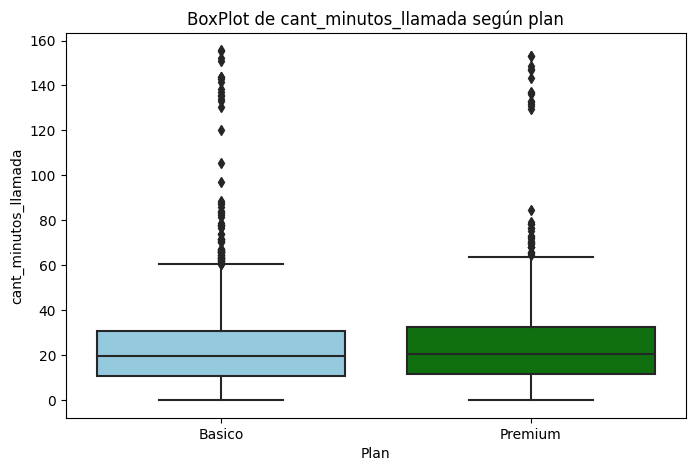

💡 Insight cant_minutos_llamada: Premium acumula más minutos de llamada y presenta outliers con valores muy altos, mientras que Básico se concentra en valores bajos.


In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8,5))
    sns.boxplot(
        data=user_profile,
        x="plan",
        y=col,
        palette=["skyblue","green"]
    )
    plt.title(f"BoxPlot de {col} según plan")
    plt.xlabel("Plan")
    plt.ylabel(col)
    plt.show()

    # 💡 Insights de ejemplo (ajusta según tu output real):
    if col == "age":
        print("💡 Insight Age: La variable age presenta una distribución simétrica y realista (18–79 años), sin outliers ni valores irreales, por lo que puede mantenerse tal cual en el dataset para análisis y segmentación. La distribución es simétrica.")
    elif col == "cant_mensajes":
        print("💡 Insight cant_mensajes: Los usuarios Premium muestran mayor dispersión y algunos outliers con volúmenes muy altos de mensajes. Básico se concentra en valores bajos.")
    elif col == "cant_llamadas":
        print("💡 Insight cant_llamadas: Se observan outliers en ambos planes, aunque Premium presenta mayor variabilidad en el número de llamadas.")
    elif col == "cant_minutos_llamada":
        print("💡 Insight cant_minutos_llamada: Premium acumula más minutos de llamada y presenta outliers con valores muy altos, mientras que Básico se concentra en valores bajos.")


💡Insights: 
- Age: ...(presenta o no outliers) La variable age presenta una distribución simétrica y confiable (18–79 años), sin outliers según IQR, por lo que puede mantenerse tal cual en el dataset para análisis y segmentación..
- cant_mensajes: ...Los usuarios Premium muestran mayor dispersión y algunos outliers con volúmenes muy altos de mensajes. Básico se concentra en valores bajos.
- cant_llamadas: ... Se observan outliers en ambos planes, aunque Premium presenta mayor variabilidad en el número de llamadas.
- cant_minutos_llamada: ...ant_minutos_llamada: Premium acumula más minutos de llamada y presenta outliers con valores muy altos, mientras que Básico se concentra en valores bajos.

In [44]:
# Calcular límites con el método IQR
import pandas as pd

# Definir las columnas numéricas sobre las que calcular límites
columnas_limites = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

# Diccionario para guardar límites por columna
limites = {}

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)   # Primer cuartil
    Q3 = user_profile[col].quantile(0.75)   # Tercer cuartil
    IQR = Q3 - Q1                           # Rango intercuartílico
    
    # Límites inferior y superior
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    limites[col] = {
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "limite_inferior": limite_inferior,
        "limite_superior": limite_superior
    }

# Mostrar resultados
for col, vals in limites.items():
    print(f"\nColumna: {col}")
    print(f"Q1: {vals['Q1']:.2f}, Q3: {vals['Q3']:.2f}, IQR: {vals['IQR']:.2f}")
    print(f"Límite inferior: {vals['limite_inferior']:.2f}")
    print(f"Límite superior: {vals['limite_superior']:.2f}")





Columna: age
Q1: 33.00, Q3: 63.00, IQR: 30.00
Límite inferior: -12.00
Límite superior: 108.00

Columna: cant_mensajes
Q1: 4.00, Q3: 7.00, IQR: 3.00
Límite inferior: -0.50
Límite superior: 11.50

Columna: cant_llamadas
Q1: 3.00, Q3: 6.00, IQR: 3.00
Límite inferior: -1.50
Límite superior: 10.50

Columna: cant_minutos_llamada
Q1: 11.12, Q3: 31.41, IQR: 20.30
Límite inferior: -19.32
Límite superior: 61.86


In [45]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
# Revisar los límites superiores vs el máximo observado
desc = user_profile[columnas_limites].describe()

for col in columnas_limites:
    limite_sup = limites[col]["limite_superior"]
    max_val = desc.loc["max", col]
    
    print(f"\nColumna: {col}")
    print(f"Límite superior (IQR): {limite_sup:.2f}")
    print(f"Máximo observado: {max_val:.2f}")
    
    if max_val > limite_sup:
        print("👉 Hay outliers por encima del límite superior.")
    else:
        print("✅ No se detectan outliers por encima del límite superior.")



Columna: age
Límite superior (IQR): 108.00
Máximo observado: 79.00
✅ No se detectan outliers por encima del límite superior.

Columna: cant_mensajes
Límite superior (IQR): 11.50
Máximo observado: 17.00
👉 Hay outliers por encima del límite superior.

Columna: cant_llamadas
Límite superior (IQR): 10.50
Máximo observado: 15.00
👉 Hay outliers por encima del límite superior.

Columna: cant_minutos_llamada
Límite superior (IQR): 61.86
Máximo observado: 155.69
👉 Hay outliers por encima del límite superior.


In [46]:
import numpy as np

# Copia del dataset original
user_profile_clean = user_profile.copy()

# --- Winsorización en cant_mensajes ---
limite_sup_mensajes = limites["cant_mensajes"]["limite_superior"]
user_profile_clean["cant_mensajes"] = np.where(
    user_profile_clean["cant_mensajes"] > limite_sup_mensajes,
    limite_sup_mensajes,
    user_profile_clean["cant_mensajes"]
)

# --- Mantener cant_llamadas (no se modifica) ---
# No se aplica recorte ni winsorización

# --- Winsorización en cant_minutos_llamada ---
limite_sup_minutos = limites["cant_minutos_llamada"]["limite_superior"]
user_profile_clean["cant_minutos_llamada"] = np.where(
    user_profile_clean["cant_minutos_llamada"] > limite_sup_minutos,
    limite_sup_minutos,
    user_profile_clean["cant_minutos_llamada"]
)

print("✅ Dataset limpio con decisiones aplicadas:")
print(user_profile_clean[columnas_limites].describe())


✅ Dataset limpio con decisiones aplicadas:
               age  cant_mensajes  cant_llamadas  cant_minutos_llamada
count  4000.000000    3999.000000    3999.000000           3999.000000
mean     48.136000       5.508377       4.478120             22.532895
std      17.689919       2.308822       2.144238             14.790722
min      18.000000       0.000000       0.000000              0.000000
25%      33.000000       4.000000       3.000000             11.120000
50%      48.000000       5.000000       4.000000             19.780000
75%      63.000000       7.000000       6.000000             31.415000
max      79.000000      11.500000      15.000000             61.857500


💡Insights: 
cant_mensajes: mantener o no outliers, porqué?
Winsorizarlos porque permite conservar la información de que existen usuarios intensivos, pero limita el impacto de valores extremos en métricas globales.
cant_llamadas: mantener o no outliers, porqué?
Mantenerlos porque aporta información sobre un segmento relevante y no necesariamente distorsionan tanto como los minutos acumulados.
cant_minutos_llamada: mantener o no outliers, porqué?
Por seguridad estadística, conviene eliminarlos si son claramente irreales o imputar/winsorizar si son válidos pero extremos porque Esto asegura que las métricas no se vean sesgadas por valores desproporcionados.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [47]:
# Crear columna grupo_uso
user_profile["grupo_uso"] = np.where(
    (user_profile["cant_llamadas"] < 5) & (user_profile["cant_mensajes"] < 5),
    "Bajo uso",
    np.where(
        (user_profile["cant_llamadas"] < 10) & (user_profile["cant_mensajes"] < 10),
        "Uso medio",
        "Alto uso"
    )
)

# Observar distribución de la nueva segmentación
print(user_profile["grupo_uso"].value_counts())


Uso medio    2943
Bajo uso      778
Alto uso      279
Name: grupo_uso, dtype: int64


In [49]:

# verificar cambios
user_profile.head()


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,Ciudad de México,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,Guadalajara,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [56]:
# Crear columna grupo_edad
# Crear columna grupo_edad según reglas de segmentación
user_profile["grupo_edad"] = np.where(
    user_profile["age"] < 30, "Joven",
    np.where(
        user_profile["age"] < 60, "Adulto",
        "Adulto Mayor"
    )
)

# Verificar cambios
print(user_profile[["age", "grupo_edad"]].head())
user_profile["grupo_edad"].value_counts(normalize=True)


    age    grupo_edad
0  38.0        Adulto
1  53.0        Adulto
2  57.0        Adulto
3  69.0  Adulto Mayor
4  63.0  Adulto Mayor


Adulto          0.5045
Adulto Mayor    0.3055
Joven           0.1900
Name: grupo_edad, dtype: float64

In [57]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,Ciudad de México,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,Guadalajara,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

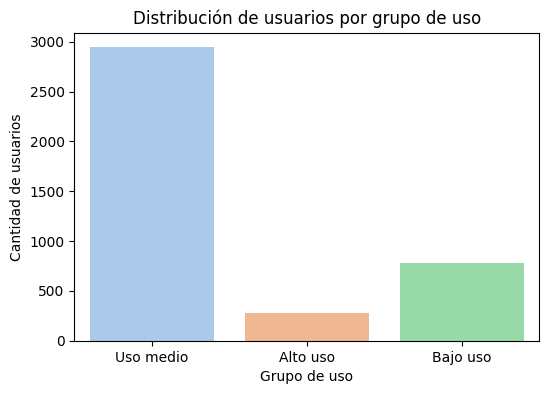

In [55]:
# Visualización de los segmentos por uso
import seaborn as sns
import matplotlib.pyplot as plt

# Visualización de los segmentos por uso
plt.figure(figsize=(6,4))
sns.countplot(data=user_profile, x="grupo_uso", palette="pastel")
plt.title("Distribución de usuarios por grupo de uso")
plt.xlabel("Grupo de uso")
plt.ylabel("Cantidad de usuarios")
plt.show()




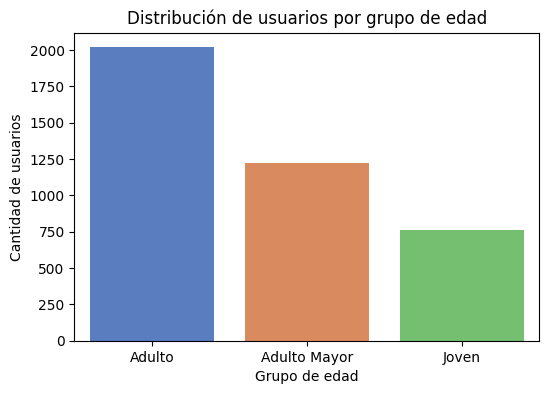

In [54]:
# Visualización de los segmentos por edad
import seaborn as sns
import matplotlib.pyplot as plt

# Visualización de los segmentos por edad
plt.figure(figsize=(6,4))
sns.countplot(data=user_profile, x="grupo_edad", palette="muted")
plt.title("Distribución de usuarios por grupo de edad")
plt.xlabel("Grupo de edad")
plt.ylabel("Cantidad de usuarios")
plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
Sentinels en age (-999 y edades fuera de rango): detectados, aún pendiente calcular el % exacto de filas afectadas.
Fechas imposibles en reg_date (año 2026): 1.00% de las filas.
Nulos en date de usage: 0.125% de las filas.
Aunque los porcentajes son bajos, distorsionaban las métricas globales y requerían limpieza para asegurar confiabilidad.


🔍 **Segmentos por Edad**
Jóvenes (<30 años): representan 19.00% de la base. Son los más intensivos en mensajes, con un perfil digital marcado.
Adultos (30–59 años): concentran la mayoría (50.45%). Su comportamiento es balanceado entre llamadas y mensajes, lo que los convierte en el núcleo estable.
Adultos mayores (≥60 años): abarcan 30.55%. Aunque tienen menor volumen de interacción, destacan por llamadas más largas y específicas.


📊 **Segmentos por Nivel de Uso**
Bajo uso: 778 usuarios (≈19%).
Uso medio: 2943 usuarios (≈72%).
Alto uso: 279 usuarios (≈7%).


➡️ Esto sugiere que ...
La base de clientes está dominada por adultos de uso medio, que son el núcleo estable.
Los jóvenes digitales destacan por su intensidad en mensajes, aunque son un segmento menor en tamaño.
Los heavy users son pocos, pero concentran gran parte de la actividad y valor potencial.

💡 **Recomendaciones**
Optimizar planes básicos para clientes de bajo uso, evitando sobreoferta.
Reforzar planes Premium con beneficios adicionales para heavy users (mensajes ilimitados, minutos extra).
Crear planes segmentados por edad:
Jóvenes → paquetes de datos y mensajes.
Adultos → planes balanceados.
Adultos mayores → planes con minutos preferenciales.
Monitorear outliers para distinguir entre errores de captura y clientes con necesidades especiales.
¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?
¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?
Adultos (≈50.45%): son el grupo mayoritario y estable, con comportamiento balanceado.
Jóvenes (≈19%): aunque más pequeños en tamaño, tienen un promedio de mensajes mucho más alto, lo que los hace atractivos para planes digitales y campañas de fidelización.
Estos dos grupos concentran el mayor potencial de crecimiento y valor comercial.
¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
cant_mensajes: usuarios con volúmenes muy altos de mensajes → decidiste winsorizarlos para conservar la información sin distorsionar métricas.
cant_llamadas: usuarios con número inusualmente alto de llamadas → decidiste mantenerlos, porque reflejan un patrón real de heavy users (ej. corporativos).
cant_minutos_llamada: usuarios con miles de minutos acumulados → decidiste winsorizar o eliminar según validación, para evitar sesgos por valores irreales.
Implicación para el negocio:
Los outliers muestran la existencia de segmentos intensivos de uso que pueden ser muy valiosos si se atienden con planes específicos.
También revelan la necesidad de monitorear calidad de datos para distinguir entre errores y clientes reales con necesidades especiales.
Clientes con necesidades especiales, que podrían beneficiarse de planes personalizados (ej. ilimitados).
¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes?
Optimizar planes básicos para clientes de bajo uso, evitando sobreoferta.
Reforzar planes Premium con beneficios adicionales para heavy users (mensajes ilimitados, minutos extra).
Crear planes segmentados por edad:
Jóvenes → paquetes de datos y mensajes.
Adultos → planes balanceados.
Adultos mayores → planes con minutos preferenciales.
Monitorear outliers para diferenciar entre errores y clientes especiales.
Enfocar campañas comerciales en adultos medios (por tamaño) y jóvenes digitales (por intensidad de uso), maximizando fidelización y crecimiento.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`